In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

# Explainability
import shap

# Display settings
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All imports successful")

All imports successful


In [2]:
import os

# paths
DATA_PATH = "../data/processed/"
MODEL_PATH = "../models/"

X_train = np.load(DATA_PATH + "X_train.npy")
X_test = np.load(DATA_PATH + "X_test.npy")
y_train = np.load(DATA_PATH + "y_train.npy")
y_test = np.load(DATA_PATH + "y_test.npy")

feature_names = pd.read_csv(DATA_PATH + "feature_names.csv")['features'].tolist()

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train churn : {y_train.mean():.1%}  ← SMOTE balanced")
print(f"y_test  churn : {y_test.mean():.1%}   ← real world distribution")
print(f"\nFeature count : {len(feature_names)}")
print(f"First 5 features: {feature_names[:5]}")

X_train shape : (8278, 40)
X_test  shape : (1409, 40)
y_train churn : 50.0%  ← SMOTE balanced
y_test  churn : 26.5%   ← real world distribution

Feature count : 40
First 5 features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender_Male']


In [3]:
# Reusable Evaluation Function
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    """
    Evaluates a classifier and prints metrics framed as business value.
    
    Parameters:
        name      : model name string (for display)
        model     : fitted sklearn-compatible model
        X_test    : test features
        y_test    : true labels
        threshold : classification threshold (default 0.5)
    
    Returns:
        dict of metrics
    """
    # Get probabilities and predictions
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= threshold).astype(int)

    # Calculate metrics
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_prob)
    pr_auc    = average_precision_score(y_test, y_prob)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"\n{'='*55}")
    print(f"  📊 {name} — Evaluation Report")
    print(f"{'='*55}")
    
    print(f"\n  CORE METRICS")
    print(f"  {'Metric':<20} {'Score':>8}   Business Meaning")
    print(f"  {'-'*50}")
    print(f"  {'Accuracy':<20} {acc:>8.1%}   Overall correct — misleading w/ imbalance")
    print(f"  {'Recall (Sensitivity)':<20} {recall:>8.1%}   % of churners we CATCH  ← #1 priority")
    print(f"  {'Precision':<20} {precision:>8.1%}   Of alerts raised, % are real churners")
    print(f"  {'F1 Score':<20} {f1:>8.1%}   Balance of recall & precision")
    print(f"  {'ROC-AUC':<20} {roc_auc:>8.3f}   Overall discrimination ability")
    print(f"  {'PR-AUC':<20} {pr_auc:>8.3f}   Better AUC metric for imbalanced data")

    print(f"\n  CONFUSION MATRIX BREAKDOWN")
    print(f"  ✅ True Positives  (caught churners)    : {tp:>5}")
    print(f"  ✅ True Negatives  (correct retentions) : {tn:>5}")
    print(f"  ⚠️ False Positives (unnecessary alerts) : {fp:>5}")
    print(f"  ❌ False Negatives (MISSED churners)    : {fn:>5}  ← most costly")

    print(f"\n  BUSINESS IMPACT (at avg ₹70/month revenue)")
    monthly_churn_cost = fn * 70
    alert_cost = fp * 70
    saved_revenue = tp * 70 * 0.3 # assume 30% of caught churners are saved
    print(f"  Revenue at risk (missed churners) : ₹{monthly_churn_cost:,.0f}/month")
    print(f"  Cost of false alerts              : ₹{alert_cost:,.0f}/month")
    print(f"  Potential revenue saved (30% save): ₹{saved_revenue:,.0f}/month")

    return {
        "model": name, "accuracy": acc, "precision": precision,
        "recall": recall, "f1": f1, "roc_auc": roc_auc, "pr_auc": pr_auc,
        "tp": tp, "tn": tn, "fp": fp, "fn": fn
    }

Key insight on Recall vs Accuracy:

Dataset has 26.5% churners. A model that predicts "nobody churns" gets 73.5% accuracy while being completely useless.

Recall tells you: "of all actual churners, how many did we catch?" That's what a business cares about.

In [4]:
# Logistic Regression Baseline (simplest possible model)

print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Done")

lr_results = evaluate_model("Logistic Regression", lr_model, X_test, y_test)

Training Logistic Regression...
Done

  📊 Logistic Regression — Evaluation Report

  CORE METRICS
  Metric                  Score   Business Meaning
  --------------------------------------------------
  Accuracy                74.0%   Overall correct — misleading w/ imbalance
  Recall (Sensitivity)    79.7%   % of churners we CATCH  ← #1 priority
  Precision               50.7%   Of alerts raised, % are real churners
  F1 Score                62.0%   Balance of recall & precision
  ROC-AUC                 0.840   Overall discrimination ability
  PR-AUC                  0.627   Better AUC metric for imbalanced data

  CONFUSION MATRIX BREAKDOWN
  ✅ True Positives  (caught churners)    :   298
  ✅ True Negatives  (correct retentions) :   745
  ⚠️ False Positives (unnecessary alerts) :   290
  ❌ False Negatives (MISSED churners)    :    76  ← most costly

  BUSINESS IMPACT (at avg ₹70/month revenue)
  Revenue at risk (missed churners) : ₹5,320/month
  Cost of false alerts              : 

In [5]:
# XGBoost with RandomizedSearchCV to get best possible combination of parameters

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

print("Setting up parameter search space...")

# search space
para_dict = {
     "n_estimators"     : [100, 200, 300, 400, 500],
    "max_depth"        : [3, 4, 5, 6],
    "learning_rate"    : [0.01, 0.05, 0.1, 0.15],
    "subsample"        : [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.7, 0.8, 0.9, 1.0],
    "min_child_weight" : [1, 3, 5],
}

# base model
xgb_base = XGBClassifier(
    eval_metric="auc",
    use_lable_encoder=False,
    random_state=42,
    n_jobs=-1 # use all cpu cores
)

# Cross-validation strategy: 5-fold, stratified (keeps 26.5% churn in each fold)
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Search starting....")
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=para_dict,
    n_iter=20,              # try 20 random combinations
    scoring="roc_auc",      # optimise for ROC-AUC
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(f"\n✅ Search complete")
print(f"Best CV ROC-AUC : {search.best_score_:.4f}")
print(f"\nBest parameters:")
for param, value in search.best_params_.items():
    print(f"  {param:<25}: {value}")

Setting up parameter search space...
Search starting....
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Search complete
Best CV ROC-AUC : 0.9377

Best parameters:
  subsample                : 0.9
  n_estimators             : 400
  min_child_weight         : 3
  max_depth                : 4
  learning_rate            : 0.05
  colsample_bytree         : 0.8


In [6]:
# Final XGBoost Model

best_params = search.best_params_
print("Best params found:")
print(best_params)

# Train final model with best params
xgb_model = XGBClassifier(
    **best_params,
    eval_metric="auc",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("\n✅ Final XGBoost model trained")

# Evaluate
xgb_results = evaluate_model("XGBoost (Tuned)", xgb_model, X_test, y_test)

Best params found:
{'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

✅ Final XGBoost model trained

  📊 XGBoost (Tuned) — Evaluation Report

  CORE METRICS
  Metric                  Score   Business Meaning
  --------------------------------------------------
  Accuracy                78.0%   Overall correct — misleading w/ imbalance
  Recall (Sensitivity)    60.2%   % of churners we CATCH  ← #1 priority
  Precision               58.3%   Of alerts raised, % are real churners
  F1 Score                59.2%   Balance of recall & precision
  ROC-AUC                 0.836   Overall discrimination ability
  PR-AUC                  0.641   Better AUC metric for imbalanced data

  CONFUSION MATRIX BREAKDOWN
  ✅ True Positives  (caught churners)    :   225
  ✅ True Negatives  (correct retentions) :   874
  ⚠️ False Positives (unnecessary alerts) :   161
  ❌ False Negatives (MISSED churners)    :   149  ← most costly

In [7]:
# Train LightGBM with Hyperparameter Tuning
import lightgbm as lgb

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    is_unbalance=False,   # SMOTE already handled imbalance
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

"""
Parameter grid explanation:
num_leaves    : KEY LightGBM param — controls tree complexity
                Higher = more complex = better fit but risk overfit
                Rule of thumb: num_leaves < 2^max_depth
max_depth     : -1 means no limit (let num_leaves control complexity)
min_child_samples : min data points per leaf (LightGBM's min_child_weight equivalent)
                    Higher = more regularization (prevents overfit on small groups)
reg_alpha     : L1 regularization (drives weights toward 0)
reg_lambda    : L2 regularization (shrinks weights smoothly)

"""

lgb_param_dist = {
    'n_estimators'       : [100, 200, 300, 500],
    'learning_rate'      : [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves'         : [20, 31, 50, 70, 100],
    'max_depth'          : [-1, 4, 6, 8],
    'subsample'          : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'   : [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples'  : [10, 20, 30, 50],
    'reg_alpha'          : [0, 0.01, 0.1, 0.5],
    'reg_lambda'         : [0, 0.01, 0.1, 0.5]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Search starting...")
lgb_search = RandomizedSearchCV(
    estimator  = lgb_base,
    param_distributions = lgb_param_dist,
    n_iter     = 30,
    scoring    = 'roc_auc',
    cv         = cv_strategy,
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1       # show progress (1 line per fold set)
)

lgb_search.fit(X_train, y_train)
print(f"\n LightGBM training complete")
print(f"   Best CV ROC-AUC : {lgb_search.best_score_:.4f}")
print(f"   Best params found:")
for k, v in lgb_search.best_params_.items():
    print(f"     {k:<25} : {v}")

Search starting...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 LightGBM training complete
   Best CV ROC-AUC : 0.9393
   Best params found:
     subsample                 : 0.6
     reg_lambda                : 0.1
     reg_alpha                 : 0.1
     num_leaves                : 70
     n_estimators              : 300
     min_child_samples         : 20
     max_depth                 : 6
     learning_rate             : 0.05
     colsample_bytree          : 0.6


In [8]:
# Final lightgbm model

best_params = lgb_search.best_params_
print("best parameters found:")
print(best_params)

lgb_model = lgb.LGBMClassifier(
    **best_params,
    objective='binary',
    metric='auc',
    is_unbalance=False,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
print("Final lightgbm model trained")

lgb_results = evaluate_model("LightGBM(Tuned)", lgb_model, X_test, y_test)

best parameters found:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 70, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Final lightgbm model trained

  📊 LightGBM(Tuned) — Evaluation Report

  CORE METRICS
  Metric                  Score   Business Meaning
  --------------------------------------------------
  Accuracy                78.1%   Overall correct — misleading w/ imbalance
  Recall (Sensitivity)    60.4%   % of churners we CATCH  ← #1 priority
  Precision               58.4%   Of alerts raised, % are real churners
  F1 Score                59.4%   Balance of recall & precision
  ROC-AUC                 0.832   Overall discrimination ability
  PR-AUC                  0.635   Better AUC metric for imbalanced data

  CONFUSION MATRIX BREAKDOWN
  ✅ True Positives  (caught churners)    :   226
  ✅ True Negatives  (correct retentions) :   874
  ⚠️ False Positives (unnecessary alerts) :   161
  ❌ 

In [9]:
# Cell 8 — Model Comparison Table

results_df = pd.DataFrame([lr_results, xgb_results, lgb_results])
results_df = results_df.set_index("model")

# Drop raw count columns for display
display_cols = ["accuracy", "recall", "precision", "f1", "roc_auc", "pr_auc"]
comparison = results_df[display_cols].copy()
comparison.columns = ["Accuracy", "Recall⭐", "Precision", "F1", "ROC-AUC", "PR-AUC"]

# Format as percentages / decimals
for col in ["Accuracy", "Recall⭐", "Precision", "F1"]:
    comparison[col] = comparison[col].map("{:.1%}".format)
for col in ["ROC-AUC", "PR-AUC"]:
    comparison[col] = comparison[col].map("{:.3f}".format)

print("\n📊 Model Comparison")
print(comparison.to_string())
print("\n⭐ = Most important metric for churn (business cost of false negatives)")


📊 Model Comparison
                    Accuracy Recall⭐ Precision     F1 ROC-AUC PR-AUC
model                                                               
Logistic Regression    74.0%   79.7%     50.7%  62.0%   0.840  0.627
XGBoost (Tuned)        78.0%   60.2%     58.3%  59.2%   0.836  0.641
LightGBM(Tuned)        78.1%   60.4%     58.4%  59.4%   0.832  0.635

⭐ = Most important metric for churn (business cost of false negatives)


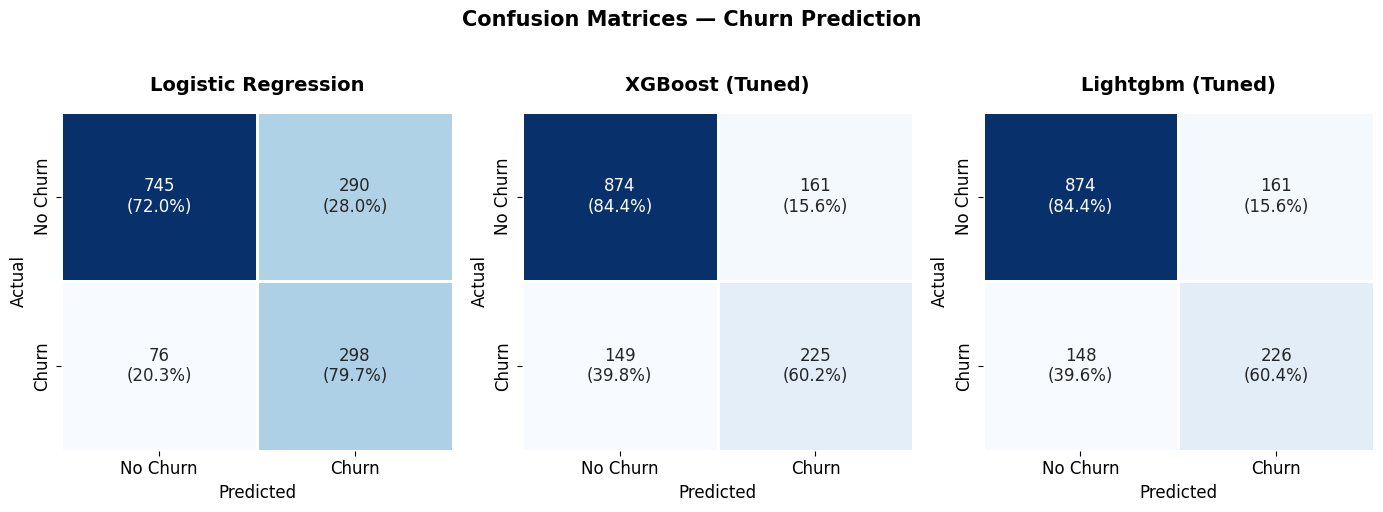

✅ Saved to data/processed/confusion_matrix.png


In [10]:
# Confusion Matrix Visualization (all models)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models_to_plot = [
    ("Logistic Regression", lr_model),
    ("XGBoost (Tuned)",     xgb_model),
    ("Lightgbm (Tuned)", lgb_model)
]

for idx, (name, model) in enumerate(models_to_plot):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate percentages for annotation
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    
    # Create annotation text: count + percentage
    annot = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row, pct_row)]
                      for row, pct_row in zip(cm, cm_pct)])
    
    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn'],
        cbar=False,
        linewidths=1,
        linecolor='white'
    )
    
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold', pad=15)
    axes[idx].set_ylabel('Actual', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=12)

plt.suptitle('Confusion Matrices — Churn Prediction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to data/processed/confusion_matrix.png")

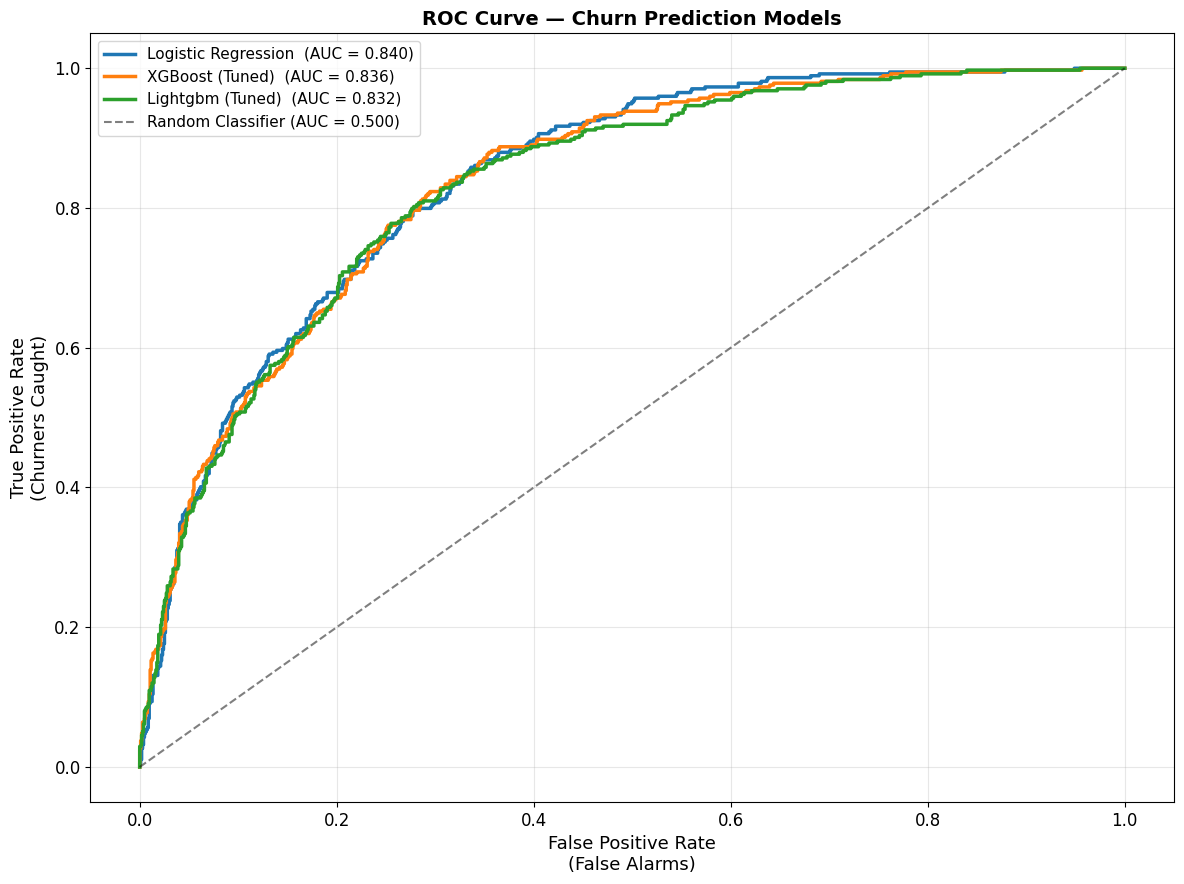

✅ Saved to data/processed/roc_curve.png


In [11]:
# ROC Curve Comparison

fig, ax = plt.subplots(figsize=(12, 9))

for name, model in models_to_plot:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5, label=f"{name}  (AUC = {auc:.3f})")

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate\n(False Alarms)', fontsize=13)
ax.set_ylabel('True Positive Rate\n(Churners Caught)', fontsize=13)
ax.set_title('ROC Curve — Churn Prediction Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to data/processed/roc_curve.png")

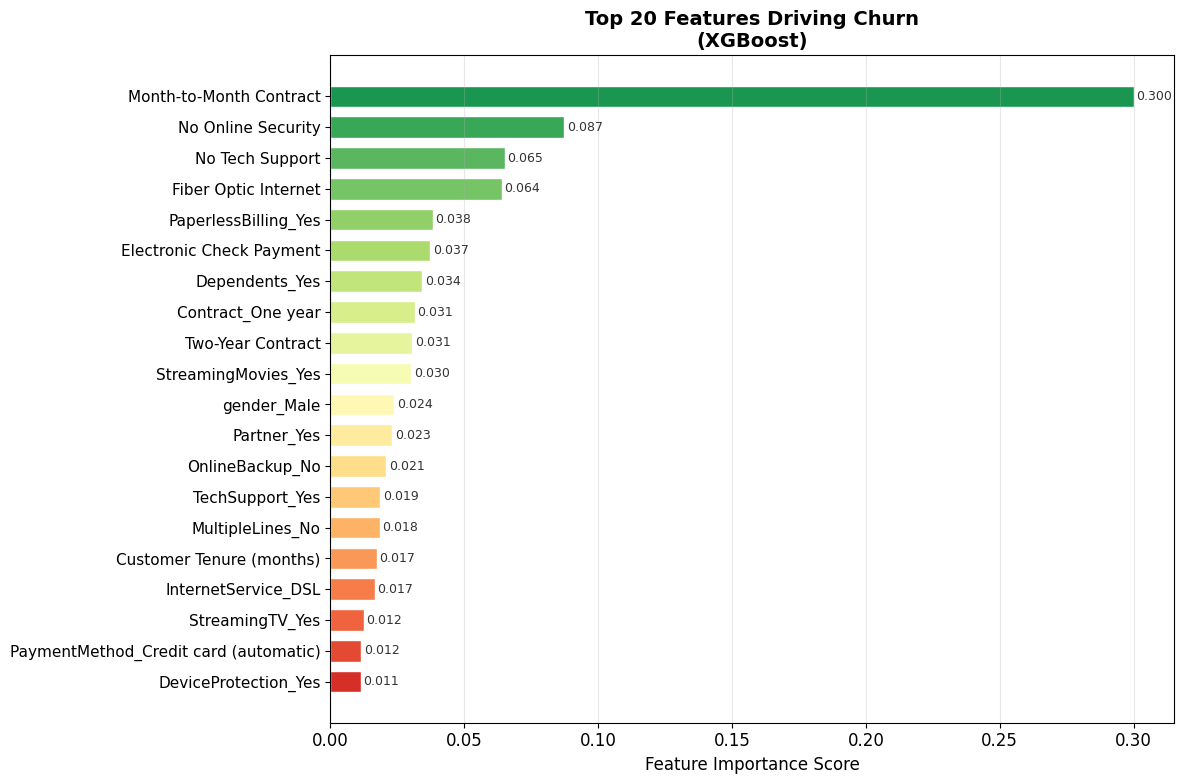

✅ Saved to data/processed/feature_importance_xgb.png


In [12]:
# Feature Importance (Top 20)

# get importance score from XGboost
importance_df = pd.DataFrame({
    "feature" : feature_names,
    "importance" : xgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

# get importance score from LightGBM
gain_importance = lgb_model.booster_.feature_importance(importance_type='gain')
importance_df_gain = pd.DataFrame({
    "feature" : feature_names,
    "importance" : gain_importance
}).sort_values('importance', ascending=False).head(20)

# Map technical feature names to business-friendly names
name_map = {
    "tenure"                         : "Customer Tenure (months)",
    "MonthlyCharges"                 : "Monthly Charges (₹)",
    "TotalCharges"                   : "Total Charges (₹)",
    "Contract_Month-to-month"        : "Month-to-Month Contract",
    "Contract_Two year"              : "Two-Year Contract",
    "InternetService_Fiber optic"    : "Fiber Optic Internet",
    "PaymentMethod_Electronic check" : "Electronic Check Payment",
    "TechSupport_No"                 : "No Tech Support",
    "OnlineSecurity_No"              : "No Online Security",
    "PaperlessBilling_1"             : "Paperless Billing",
}
importance_df["label"] = importance_df["feature"].map(name_map).fillna(importance_df["feature"])
# importance_df_gain.head(20)
# Plot
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance_df)))

bars = ax.barh(
    range(len(importance_df)),
    importance_df["importance"],
    color=colors,
    edgecolor='white',
    height=0.7
)

ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df["label"], fontsize=11)
ax.invert_yaxis()   # highest importance at top

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Top 20 Features Driving Churn\n(XGBoost)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, importance_df["importance"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to data/processed/feature_importance_xgb.png")

In [13]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score

models = {
    "XGBoost" : xgb_model,
    "LightGBM": lgb_model
}

print(f"{'Model':<12} {'ROC-AUC':>9} {'Recall':>9} {'F1':>9} {'Inference Speed':>16}")
print("-" * 58)

import time

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    auc    = roc_auc_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    
    # Inference speed (important for API latency)
    start = time.time()
    for _ in range(100):
        model.predict_proba(X_test[:1])   # single customer, 100 times
    elapsed = (time.time() - start) / 100 * 1000  # ms per prediction
    
    print(f"{name:<12} {auc:>9.4f} {recall:>9.1%} {f1:>9.1%} {elapsed:>13.2f}ms")

Model          ROC-AUC    Recall        F1  Inference Speed
----------------------------------------------------------
XGBoost         0.8364     60.2%     59.2%          0.32ms
LightGBM        0.8321     60.4%     59.4%          1.07ms


SHAP (SHapley Additive exPlanations) answers: "For THIS specific customer, which features pushed the prediction toward churn and by how much?"

In [14]:
# SHAP explainablity

print("Building SHAP explainer...")

# TreeExplainer is optimised for tree-based models (XGBoost, LightGBM, Random Forest)
# It calculates EXACT Shapley values — not approximations
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
# We use a sample for speed during exploration — full set for production
X_test_df = pd.DataFrame(X_test, columns=feature_names)

shap_values = explainer(X_test_df) # returns Explanation object (newer API)
shap_array = explainer.shap_values(X_test_df) # returns raw numpy array (for saving)

print(f"   SHAP values shape: {shap_array.shape}")
print(f"   Rows: {shap_array.shape[0]} customers")
print(f"   Cols: {shap_array.shape[1]} features")
print(f"\n   For each customer, each feature has a SHAP value:")
print(f"   Positive SHAP → pushes prediction toward CHURN")
print(f"   Negative SHAP → pushes prediction toward RETAIN")

Building SHAP explainer...
   SHAP values shape: (1409, 40)
   Rows: 1409 customers
   Cols: 40 features

   For each customer, each feature has a SHAP value:
   Positive SHAP → pushes prediction toward CHURN
   Negative SHAP → pushes prediction toward RETAIN


Generating SHAP summary plot...


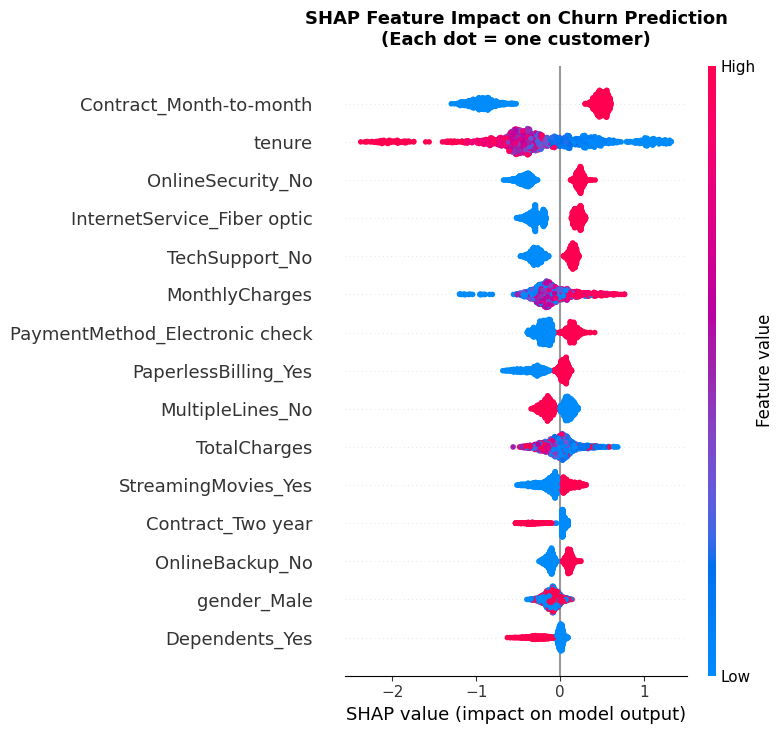

✅ Saved to data/processed/shap_summary.png

How to read this plot:
  • Each row = one feature
  • Each dot = one customer's SHAP value for that feature
  • Color: Red = high feature value | Blue = low feature value
  • X-axis: negative = pushes toward retention, positive = pushes toward churn


In [15]:
# Cell 13 — SHAP Summary Plot

print("Generating SHAP summary plot...")

fig, ax = plt.subplots(figsize=(10,20))

shap.summary_plot(
    shap_array,
    X_test_df,
    max_display=15, # top 15 features
    show=False,
    plot_type="dot" # dot plot shows distribution, not just mean
)

plt.title("SHAP Feature Impact on Churn Prediction\n(Each dot = one customer)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to data/processed/shap_summary.png")
print()
print("How to read this plot:")
print("  • Each row = one feature")
print("  • Each dot = one customer's SHAP value for that feature")
print("  • Color: Red = high feature value | Blue = low feature value")
print("  • X-axis: negative = pushes toward retention, positive = pushes toward churn")

Found 116 correctly predicted High rsik Churners

  Customer #20 Analysis
  Predicted churn probability : 81.8%
  Actual outcome              : CHURNED


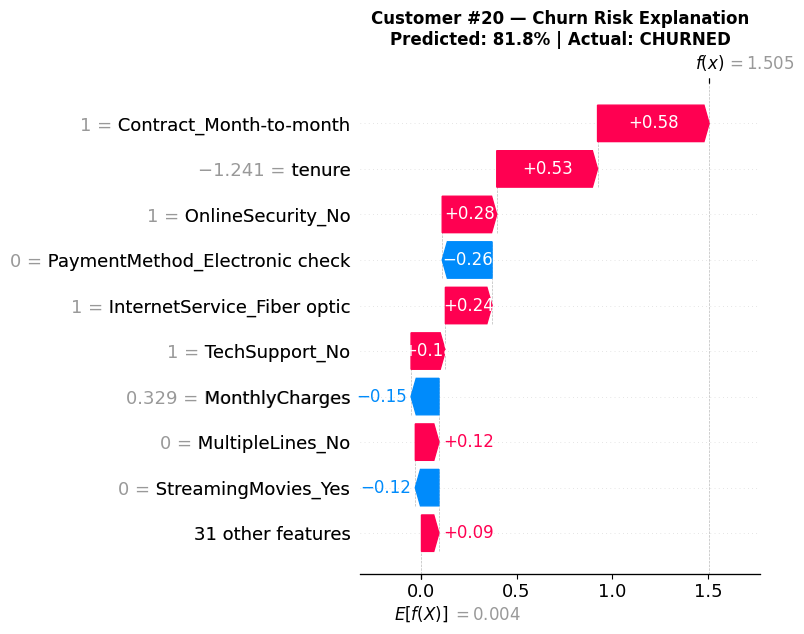


 Top 5 factors(for API to explain in plain English):
  ⬆️ CHURN risk | Contract_Month-to-month             = 1.00  (SHAP: +0.5822)
  ⬆️ CHURN risk | tenure                              = -1.24  (SHAP: +0.5259)
  ⬆️ CHURN risk | OnlineSecurity_No                   = 1.00  (SHAP: +0.2845)
  ⬇️ retention | PaymentMethod_Electronic check      = 0.00  (SHAP: -0.2601)
  ⬆️ CHURN risk | InternetService_Fiber optic         = 1.00  (SHAP: +0.2435)


In [16]:
# SHAP Waterfall for individual customer

def explain_single_customer(customer_idx, X_test_df, shap_values_obj, y_test, y_prob):
    """
    Shows exactly WHY the model predicted churn for one specific customer.
    This is what gets embedded in the API response later.
    """
    actual = "CHURNED" if y_test[customer_idx] == 1 else "RETAINED"
    predicted = y_prob[customer_idx]
    
    print(f"\n{'='*55}")
    print(f"  Customer #{customer_idx} Analysis")
    print(f"  Predicted churn probability : {predicted:.1%}")
    print(f"  Actual outcome              : {actual}")
    print(f"{'='*55}")
    # waterfall plot
    plt.figure(figsize=(10,6))
    shap.waterfall_plot(shap_values_obj[customer_idx], max_display=10, show=False)
    plt.title(f"Customer #{customer_idx} — Churn Risk Explanation\n"
        f"Predicted: {predicted:.1%} | Actual: {actual}",fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../data/processed/shap_customer_{customer_idx}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # top 3 Risk factors in plain text(this feeds into API)
    customer_shap = shap_array[customer_idx]
    feature_shap = list(zip(feature_names, customer_shap))

    # sort by absolute value, +/- will be treated as same(only magnitude)
    top_factors = sorted(feature_shap, key=lambda x:abs(x[1]), reverse=True)[:5]

    print(f"\n Top 5 factors(for API to explain in plain English):")
    for feature, shap_val in top_factors:
        direction = "⬆️ CHURN risk" if shap_val > 0 else "⬇️ retention"
        value = X_test_df.iloc[customer_idx][feature]
        print(f"  {direction} | {feature:35s} = {value:.2f}  (SHAP: {shap_val:+.4f})")

    return top_factors

# get probabilities for labeling
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# high risk customers
high_risk_idx = np.where((y_prob > 0.75) & (y_test==1))[0]
print(f"Found {len(high_risk_idx)} correctly predicted High rsik Churners")

if len(high_risk_idx) > 0:
    sample_idx = high_risk_idx[0]
    top_factors = explain_single_customer(sample_idx, X_test_df, shap_values, y_test, y_prob_xgb)

In [17]:
# threshold optimization

# y_pred = xgb_model.predict(X_test)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

# Calculate F1 at each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Default threshold (0.50) results:")
default_results = evaluate_model("XGBoost @ 0.50", xgb_model, X_test, y_test, threshold=0.50)

print(f"\n\nOptimal threshold ({best_threshold:.2f}) results:")
optimal_results = evaluate_model(f"XGBoost @ {best_threshold:.2f}", xgb_model, X_test, y_test, threshold=best_threshold)

print(f"\n📌 RECOMMENDATION: Use threshold = {best_threshold:.2f}")
print(f"   This threshold maximises F1 score on the test set.")
print(f"   the API will use it.")

# Save threshold for Day 4
BEST_THRESHOLD = best_threshold
print(f"\nBEST_THRESHOLD = {BEST_THRESHOLD:.4f}") # predict.py will use this

Default threshold (0.50) results:

  📊 XGBoost @ 0.50 — Evaluation Report

  CORE METRICS
  Metric                  Score   Business Meaning
  --------------------------------------------------
  Accuracy                78.0%   Overall correct — misleading w/ imbalance
  Recall (Sensitivity)    60.2%   % of churners we CATCH  ← #1 priority
  Precision               58.3%   Of alerts raised, % are real churners
  F1 Score                59.2%   Balance of recall & precision
  ROC-AUC                 0.836   Overall discrimination ability
  PR-AUC                  0.641   Better AUC metric for imbalanced data

  CONFUSION MATRIX BREAKDOWN
  ✅ True Positives  (caught churners)    :   225
  ✅ True Negatives  (correct retentions) :   874
  ⚠️ False Positives (unnecessary alerts) :   161
  ❌ False Negatives (MISSED churners)    :   149  ← most costly

  BUSINESS IMPACT (at avg ₹70/month revenue)
  Revenue at risk (missed churners) : ₹10,430/month
  Cost of false alerts              : ₹11,270

In [26]:
# save models

# 1. XGBoost model
joblib.dump(xgb_model, "../models/churn_model.pkl")
print("✅ Saved: models/churn_model.pkl")

# 2. SHAP Explainer (needs raw model, not pipeline — that's why they're separate)
joblib.dump(explainer, "../models/shap_explainer.pkl")
print("✅ Saved: models/shap_explainer.pkl")

# Final prediction at optimal threshold
y_pred_optimal = (y_prob_xgb >= BEST_THRESHOLD).astype(int)

# 3. Model metadata — threshold, feature names, evaluation metrics
model_metadata = {
    "model_type"        : "XGBClassifier",    
    "n_features"        : len(feature_names),
    "feature_names"     : feature_names,
    "training_date"     : pd.Timestamp.now().isoformat(),
    "best_threshold"    : float(BEST_THRESHOLD),
    "roc_auc_test"      : float(optimal_results["roc_auc"]),
    "recall_test"       : float(optimal_results["recall"]),
    "precision_test"    : float(optimal_results["precision"]),
    "f1_test"           : float(optimal_results["f1"]),
}

import json
with open("../models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)
    print("✅ Saved: models/model_metadata.json")

print("\nFiles in models/:")
for f in os.listdir("../models"):
    size = os.path.getsize(f"../models/{f}") / 1024
    print(f"  {f:<30} {size:.1f} KB")

✅ Saved: models/churn_model.pkl
✅ Saved: models/shap_explainer.pkl
✅ Saved: models/model_metadata.json

Files in models/:
  churn_model.pkl                567.6 KB
  model_matadata.json            1.6 KB
  model_matedata.json            1.6 KB
  model_metadata.json            1.5 KB
  preprocessor.pkl               9.1 KB
  shap_explainer.pkl             1607.9 KB


In [28]:
# adding this block because we need justifiable boundaries for categorizing churn risk level of customer
# now using percentiles of training score distribution so that if customer is in 95th percentile then rsik level is critical and same goes for other level too.
train_probs = model.predict_proba(X_train)[:, 1]

boundaries = {
    "threshold":        float(BEST_THRESHOLD),
    "medium_boundary":  float(np.percentile(train_probs, 60)),  # 60th percentile
    "high_boundary":    float(np.percentile(train_probs, 80)),  # 80th percentile
    "critical_boundary":float(np.percentile(train_probs, 95))   # 95th percentile
}

model_metadata.update(boundaries)

In [29]:

with open("../models/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)
    print("✅ Saved: models/model_metadata.json")

✅ Saved: models/model_metadata.json


In [30]:
model_metadata

{'model_type': 'XGBClassifier',
 'n_features': 40,
 'feature_names': ['tenure',
  'MonthlyCharges',
  'TotalCharges',
  'SeniorCitizen',
  'gender_Male',
  'Partner_Yes',
  'Dependents_Yes',
  'PhoneService_Yes',
  'MultipleLines_No',
  'MultipleLines_No phone service',
  'MultipleLines_Yes',
  'InternetService_DSL',
  'InternetService_Fiber optic',
  'InternetService_No',
  'OnlineSecurity_No',
  'OnlineSecurity_No internet service',
  'OnlineSecurity_Yes',
  'OnlineBackup_No',
  'OnlineBackup_No internet service',
  'OnlineBackup_Yes',
  'DeviceProtection_No',
  'DeviceProtection_No internet service',
  'DeviceProtection_Yes',
  'TechSupport_No',
  'TechSupport_No internet service',
  'TechSupport_Yes',
  'StreamingTV_No',
  'StreamingTV_No internet service',
  'StreamingTV_Yes',
  'StreamingMovies_No',
  'StreamingMovies_No internet service',
  'StreamingMovies_Yes',
  'Contract_Month-to-month',
  'Contract_One year',
  'Contract_Two year',
  'PaperlessBilling_Yes',
  'PaymentMethod